(0.0, 206062.5)

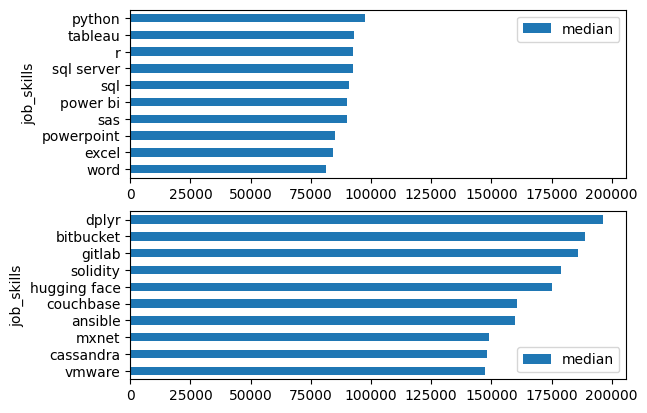

In [6]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
#df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df = df[df["job_title_short"] == "Data Analyst"] 
df = df[df["job_country"] == "United States"]

df = df.explode("job_skills")


df = df.dropna(subset="salary_year_avg")
df = df.dropna(subset="job_skills")


df = df.sort_values("job_skills")


tabla = df.groupby("job_skills")["salary_year_avg"].agg(["count", "median"])


top_count = tabla.sort_values(by="count", ascending=False).head(10).sort_values(by="median")


top_median = tabla.sort_values(by="median", ascending=False).head(10)


fig, ax = plt.subplots(2,1)

top_count.plot(kind="barh", y = "median", ax=ax[0])
top_median.plot(kind="barh", y = "median", ax=ax[1])
ax[1].invert_yaxis()
ax[0].set_xlim(ax[1].get_xlim())





